# PCA of sea level pressure fields (ERA5, North Pacific)

Summarize daily ERA5 pressure over the selected **North Pacific rectangle** with two PCA models: pressure alone, and pressure plus its spatial-gradient predictor.

The input is a preprocessed ERA5 dataset, already cropped and block-averaged onto a **2° grid**:

- Latitude: **20°N to 60°N**.
- Longitude: **165°W to 105°W**.

Use 1979–2025, inspect the regional fields, fit the two PCA models, explore EOFs and PCs, and save regional models for `waves_regression.ipynb`.

In [1]:
import logging
import os
import warnings
warnings.filterwarnings("ignore")

# Hide bluemath_tk PCA log messages below ERROR
logging.getLogger("PCA").setLevel(logging.ERROR)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from bluemath_tk.core.operations import spatial_gradient
from bluemath_tk.datamining.pca import PCA

## 1. Load the regional ERA5 sea level pressure

The dataset is served from the GeoOcean THREDDS server. It was prepared from hourly 0.25° ERA5 fields by cropping the North Pacific rectangle (20°N–60°N, 165°W–105°W) and averaging each **8 × 8 spatial block** (0.25° → 2°) over 1979–2025. Values are stored in Pa; longitudes follow the 0–360° convention.

After loading and converting to hPa, a **Natural Earth 50m land mask** excludes every 2° grid cell whose center falls on land. Land cells become NaN and are excluded by BlueMath before PCA; they are not filled with zeros. Cartopy may download the land geometries on first use.

In [2]:
from pathlib import Path

south, north = 20, 60
west, east = -165, -105
region_id = "north_pacific_20N-60N_165W-105W"
resolution = 2  # degrees
map_center = ((west + east) / 2, (south + north) / 2)

# Download the regional dataset once into toolkit/data/outputs (skipped if it already exists).
# --no-check-certificate: the GeoOcean server certificate expired on 2026-10-01.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "toolkit" / "data").is_dir())
data_path = repo_root / "toolkit" / "data" / "outputs"
data_path.mkdir(parents=True, exist_ok=True)
data_url = "https://geoocean.unican.es/thredds/fileServer/rawData/GEOOCEAN/BlueMath_Course_Corvallis/era5_north_pacific_20N-60N_165W-105W_msl_1979-2025_2deg_blockmean_Pa.nc"
reduced_file = data_path / Path(data_url).name
!wget -nc -q --show-progress --no-check-certificate -P "{data_path}" "{data_url}"

In [3]:
# Load the regional dataset, close the connection, and convert Pa -> hPa in memory.
with xr.open_dataset(reduced_file) as reduced:
    msl = (reduced.msl.load() / 100).transpose("time", "latitude", "longitude")
msl.attrs.update(long_name="North Pacific mean sea level pressure", units="hPa")
assert bool(((msl.latitude >= south) & (msl.latitude <= north)).all())
assert bool(((msl.longitude >= west % 360) & (msl.longitude <= east % 360)).all())
print(f"Regional grid: {msl.sizes['latitude']} × {msl.sizes['longitude']} regional cells")
msl
# Ocean mask: retain a grid cell only if its center is ocean.
# Natural Earth uses -180..180 longitudes; ERA5 uses 0..360.
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

land = prep(unary_union(list(cfeature.LAND.with_scale("50m").geometries())))
source_lon, source_lat = np.meshgrid(
    (msl.longitude.values + 180) % 360 - 180, msl.latitude.values
)
ocean_mask = xr.DataArray(
    np.array([
        not land.intersects(Point(lon, lat))
        for lon, lat in zip(source_lon.ravel(), source_lat.ravel())
    ]).reshape(source_lon.shape),
    coords={"latitude": msl.latitude, "longitude": msl.longitude},
    dims=("latitude", "longitude"),
    name="ocean_mask",
)
ocean_mask.attrs["description"] = "Grid-cell center is ocean using Natural Earth 50m land"
if not bool(ocean_mask.any()):
    raise ValueError("No ocean grid cells remain in the selected region.")
msl = msl.where(ocean_mask)
print(f"Ocean predictors: {int(ocean_mask.sum())} / {ocean_mask.size} grid cells")
msl

Regional grid: 20 × 30 regional cells
Ocean predictors: 429 / 600 grid cells


<xarray.DataArray 'msl' (time: 17167, latitude: 20, longitude: 30)> Size: 41MB
array([[[ 996.7125 ,  998.82874,        nan, ...,        nan,
                nan,        nan],
        [ 996.53125,  998.5588 , 1000.64374, ...,        nan,
                nan,        nan],
        [ 997.89874,  999.6163 , 1001.6875 , ...,        nan,
                nan,        nan],
        ...,
        [1018.57874, 1018.15625, 1017.615  , ..., 1017.98627,
                nan,        nan],
        [1018.08374, 1017.6887 , 1017.20874, ..., 1016.8837 ,
         1015.73376,        nan],
        [1017.0775 , 1016.73376, 1016.295  , ..., 1015.9125 ,
         1014.9625 , 1013.7587 ]],

       [[1011.4275 , 1013.6788 ,        nan, ...,        nan,
                nan,        nan],
        [1008.3663 , 1010.275  , 1012.20374, ...,        nan,
                nan,        nan],
        [1005.295  , 1006.7275 , 1008.26624, ...,        nan,
                nan,        nan],
...
        [1016.67126, 1016.5425 , 1016.42   , ..., 1014.7625 ,
                nan,        nan],
        [1015.3675 , 1015.17   , 1015.0737 , ..., 1014.28125,
         1013.8575 ,        nan],
        [1014.10376, 1014.     , 1013.9288 , ..., 1013.6213 ,
         1013.54626, 1013.33124]],

       [[1029.0913 , 1028.1038 ,        nan, ...,        nan,
                nan,        nan],
        [1030.1538 , 1028.795  , 1026.45   , ...,        nan,
                nan,        nan],
        [1030.7013 , 1029.0825 , 1025.8938 , ...,        nan,
                nan,        nan],
        ...,
        [1017.14124, 1017.1675 , 1017.14124, ..., 1017.08124,
                nan,        nan],
        [1015.46875, 1015.405  , 1015.47   , ..., 1016.675  ,
         1016.1825 ,        nan],
        [1014.10376, 1014.1075 , 1014.1975 , ..., 1016.0625 ,
         1015.94   , 1015.5225 ]]], shape=(17167, 20, 30), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
  * latitude   (latitude) float64 160B 59.12 57.12 55.12 ... 25.12 23.12 21.12
  * longitude  (longitude) float64 240B 195.9 197.9 199.9 ... 249.9 251.9 253.9
Attributes:
    long_name:  North Pacific mean sea level pressure
    units:      hPa

## 2. Explore the regional data

Plot the block-averaged pressure for one day over the **North Pacific rectangle**. Every subsequent PCA uses this domain.

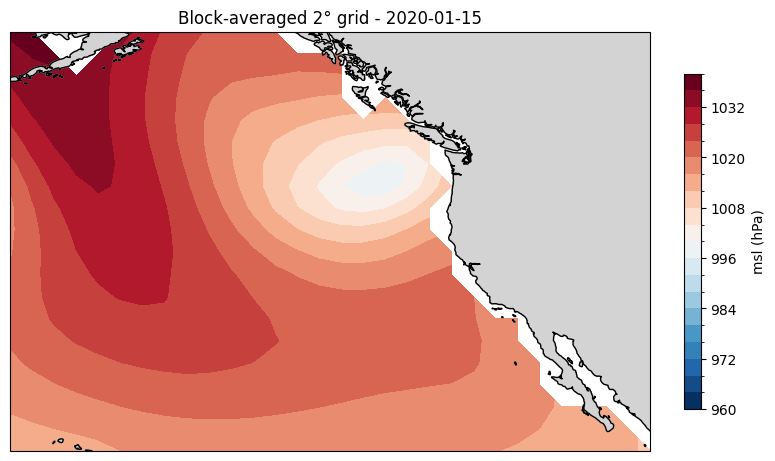

In [4]:
date = "2020-01-15"
proj = ccrs.PlateCarree(central_longitude=map_center[0])
levels = np.arange(960, 1041, 4)

fig, ax = plt.subplots(figsize=(8, 4.5), subplot_kw={"projection": proj}, layout="constrained")
msl.sel(time=date).plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r",
    cbar_kwargs={"label": "msl (hPa)", "shrink": 0.8},
)
ax.add_feature(cfeature.LAND, color="lightgrey", zorder=2)
ax.coastlines(zorder=3)
ax.set_title(f"Block-averaged {resolution:g}° grid - {date}");

As in `PCA_theory.ipynb`, the data are a **3D block** (`time` × `latitude` × `longitude`), and PCA needs a 2D matrix. Each daily map is flattened into one row, so `time` gives the observations and every retained ocean grid point is a feature:

In [5]:
n_times, n_lat, n_lon = msl.shape
print(f"{n_times} days x {int(ocean_mask.sum())} ocean predictors (land cells excluded)")


17167 days x 429 ocean predictors (land cells excluded)


## 3. Fit the PCA

The call is the same as in the theory notebook:

- `vars_to_stack=["msl"]`: the variable used as predictor.
- `coords_to_stack=["latitude", "longitude"]`: every retained ocean grid point becomes a feature (column).
- `pca_dim_for_rows="time"`: every day becomes an observation (row).
- `n_components=0.95`: keep as many components as needed to explain **95% of the variance**.

All-NaN land columns are dropped by BlueMath. The data are standardized by default (`scale_data=True`), so every grid point contributes with unit variance.

In [6]:
era5 = msl.to_dataset()

pca = PCA(n_components=0.95)
pcs = pca.fit_transform(
    data=era5,
    vars_to_stack=["msl"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

print(f"{pca.pca.n_components_} components explain {pca.cumulative_explained_variance_ratio[-1]:.1%} of the variance")
pcs

10 components explain 95.5% of the variance


<xarray.Dataset> Size: 824kB
Dimensions:      (time: 17167, n_component: 10)
Coordinates:
  * time         (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * n_component  (n_component) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    PCs          (time, n_component) float32 687kB -13.86 -12.49 ... -4.222
    stds         (n_component) float32 40B 12.02 10.29 7.842 ... 2.4 2.319 2.005

### How many components?

The retained ocean grid points are compressed into a smaller set of components that retain 95% of the variance. The plots below show how much each component contributes and how many are needed to reach different cumulative thresholds.


[Text(0.5, 0, 'Number of components'),
 Text(0, 0.5, 'Cumulative explained variance (%)'),
 Text(0.5, 1.0, 'Cumulative')]

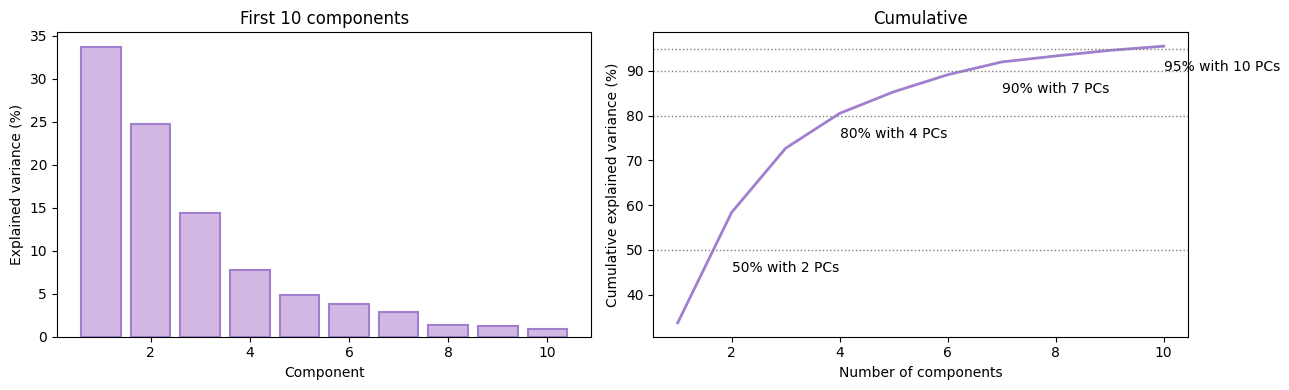

In [7]:
n = np.arange(1, pca.pca.n_components_ + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), tight_layout=True)
axes[0].bar(n[:20], pca.explained_variance_ratio[:20] * 100, color="#d4b8e4", edgecolor="#a07fcf", linewidth=1.5)
axes[0].set(xlabel="Component", ylabel="Explained variance (%)", title=f"First {min(20, len(n))} components")
axes[1].plot(n, pca.cumulative_explained_variance_ratio * 100, color="#a07fcf", linewidth=2)
for threshold in [50, 80, 90, 95]:
    k = np.argmax(pca.cumulative_explained_variance_ratio * 100 >= threshold) + 1
    axes[1].axhline(threshold, color="grey", linestyle=":", linewidth=1)
    axes[1].annotate(f"{threshold}% with {k} PCs", (k, threshold), xytext=(k, threshold - 5))
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance (%)", title="Cumulative")

## 4. Reconstruct a daily field

Each day is now described only by its PC values. `inverse_transform` goes back from those values to a full pressure map. Comparing it with the original shows how much is lost with the retained components.

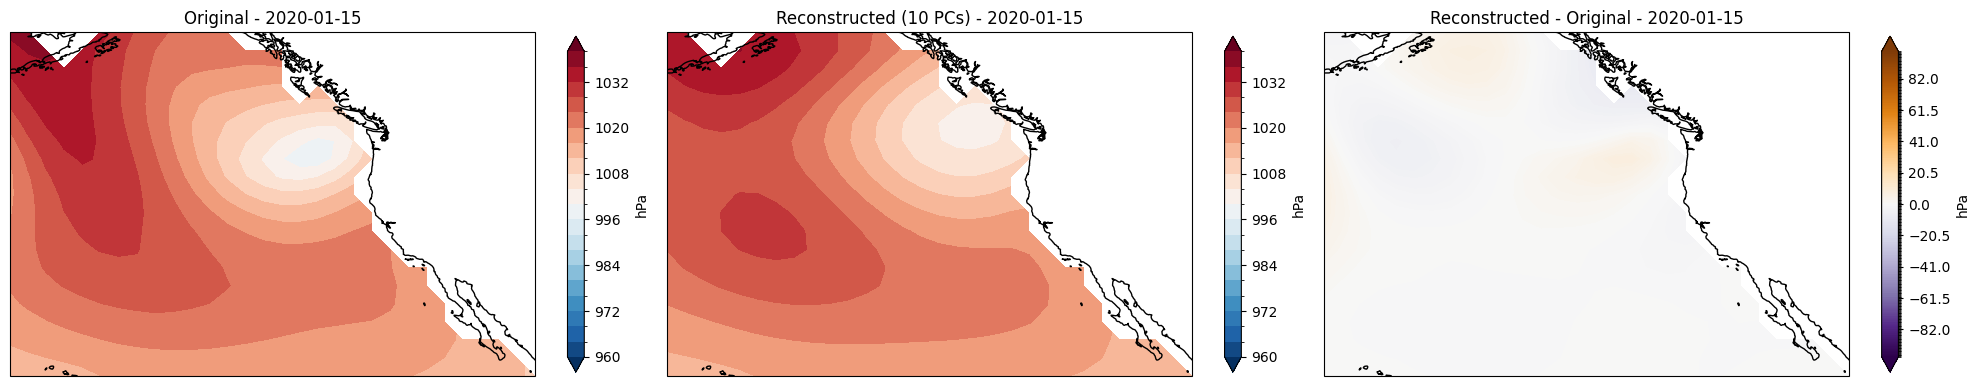

In [8]:
reconstructed = pca.inverse_transform(PCs=pcs.sel(time=[date])).msl.squeeze()
original = msl.sel(time=date)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5), subplot_kw={"projection": proj}, tight_layout=True)
panels = [
    (original, "Original", levels, "RdBu_r"),
    (reconstructed, f"Reconstructed ({pca.pca.n_components_} PCs)", levels, "RdBu_r"),
    (reconstructed - original, "Reconstructed - Original", np.arange(-100, 100.5, 0.5), "PuOr_r"),
]
for ax, (field, title, lev, cmap) in zip(axes, panels):
    field.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(), levels=lev, cmap=cmap, extend="both",
        cbar_kwargs={"label": "hPa", "shrink": 0.8},
    )
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

## 5. Spatial modes (EOFs)

These EOFs describe covariance within the selected North Pacific rectangle. They are newly fitted regional patterns, not crops of the full-Pacific EOFs. Their signs are arbitrary. Inspect the maps together with their PCs before assigning a circulation interpretation; physical interpretations from the earlier full-Pacific analysis do not automatically apply here.


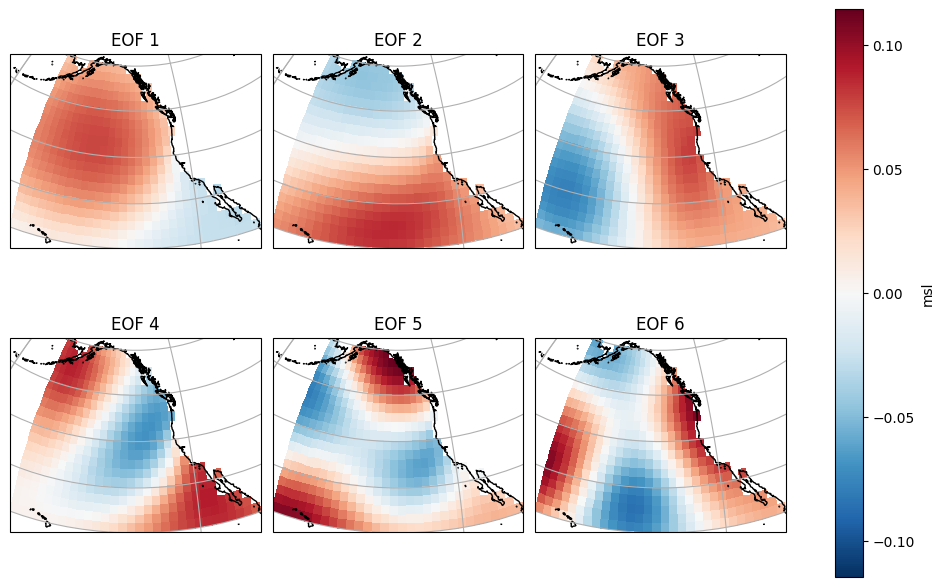

In [9]:
pca.plot_eofs(vars_to_plot=["msl"], num_eofs=min(6, pca.pca.n_components_), map_center=map_center)

## 6. Temporal indices (PCs)

Show the first three regional PCs over the full record and a zoom for 2015–2018. Each score describes the daily amplitude of its regional EOF. The explained-variance ratios refer to the cropped pressure field.


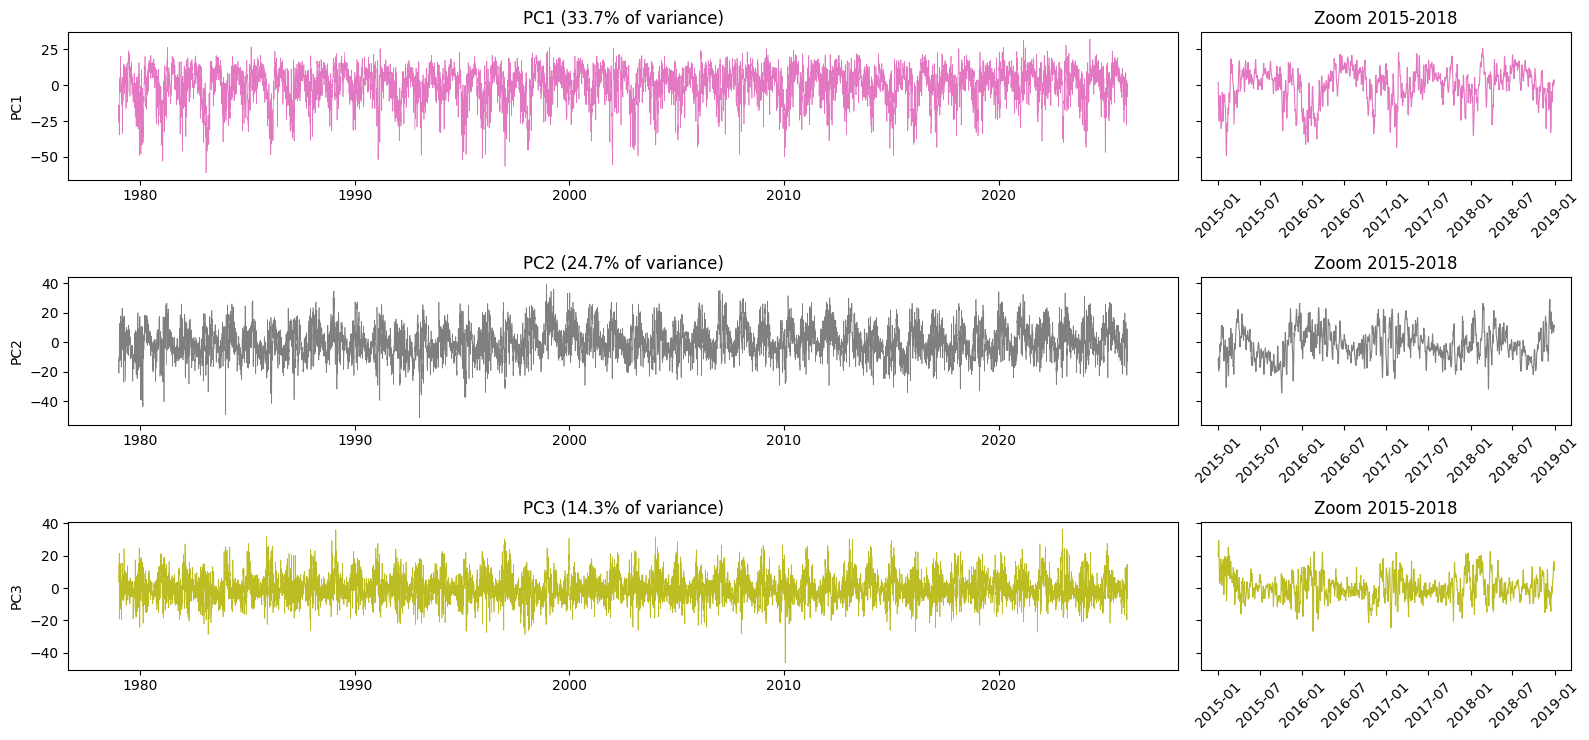

In [10]:
n_pcs = min(3, pcs.sizes["n_component"])

fig, axes = plt.subplots(n_pcs, 2, figsize=(16, 2.5 * n_pcs), sharey="row", tight_layout=True,
                         gridspec_kw={"width_ratios": [3, 1]})
for i in range(n_pcs):
    pc = pcs.PCs.isel(n_component=i)
    ratio = pca.explained_variance_ratio[i]

    axes[i, 0].plot(pc.time, pc, color = f"C{i + 6}", linewidth=0.5)
    # axes[i, 0].plot(pc.time, pc.rolling(time=365, center=True).mean(), color=f"C{i}", linewidth=1.5)
    axes[i, 0].set(ylabel=f"PC{i + 1}", title=f"PC{i + 1} ({ratio:.1%} of variance)")

    zoom = pc.sel(time=slice("2015", "2018"))
    axes[i, 1].plot(zoom.time, zoom, color=f"C{i + 6}", linewidth=0.8)
    axes[i, 1].set(title="Zoom 2015-2018")
    axes[i, 1].tick_params(axis="x", labelrotation=45)

## 7. Adding the msl gradient

Pressure gradients drive wind, so we add a predictor of spatial pressure variation alongside msl. We compute it **after coarsening**, from the same 2° pressure fields used above, with [`bluemath_tk.core.operations.spatial_gradient`](https://geoocean.github.io/BlueMath_tk/_modules/bluemath_tk/core/operations.html#spatial_gradient). The input is a `DataArray` ordered as (`time`, `latitude`, `longitude`).

The published implementation sums squared neighboring pressure differences, with a cosine correction for longitude differences, and leaves the outermost grid cells at zero. It does not take a square root or divide by grid spacing in physical distance. Here `msl_gradient` therefore represents a **squared pressure-difference predictor**, in **hPa²** for our hPa input, rather than a gradient magnitude in hPa/km. We correct its metadata because the function assigns a fixed unit label unrelated to the input pressure units. The zero-valued boundary is an implementation convention, not an observed absence of pressure variation.

The gradient is computed from masked pressure. Its mask requires the center and all four neighbors to be ocean; coastal stencils and the outer boundary are excluded from the combined PCA.


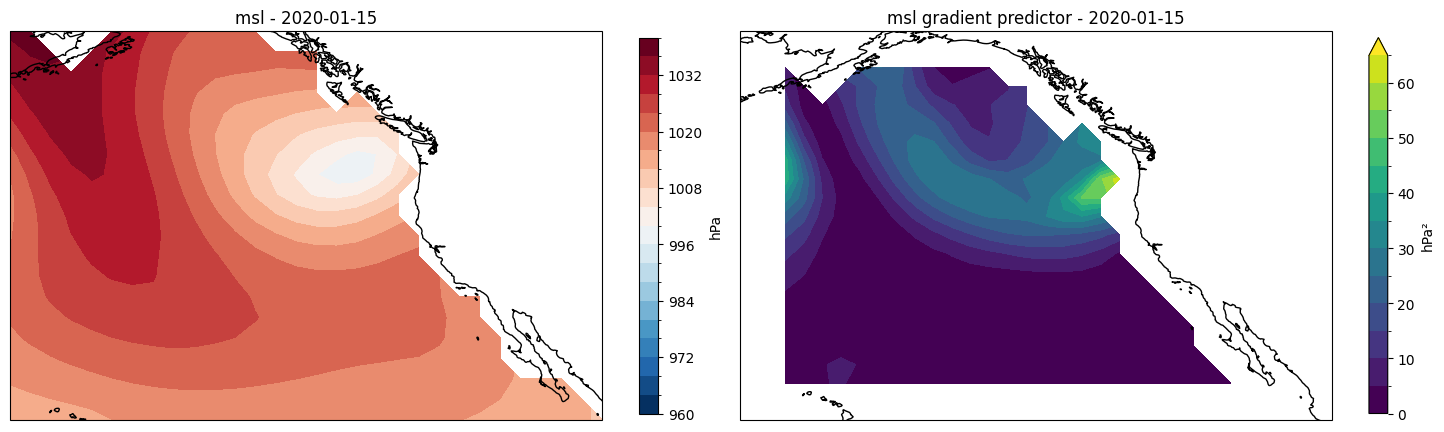

In [11]:
# Require ocean at the center and all four neighbors; exclude outer boundaries.
gradient_mask = ocean_mask.copy()
for dim in ("latitude", "longitude"):
    for offset in (-1, 1):
        gradient_mask = gradient_mask & ocean_mask.shift({dim: offset}, fill_value=False)
if not bool(gradient_mask.any()):
    raise ValueError("No ocean gradient stencils remain in the selected region.")
era5["msl_gradient"] = spatial_gradient(msl).where(gradient_mask)
era5["msl_gradient"].attrs = {
    "long_name": "Squared spatial pressure-difference predictor",
    "units": "hPa^2",
    "description": "BlueMath spatial_gradient on the coarsened hPa field; land, coastal stencils and outer boundary excluded",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={"projection": proj}, tight_layout=True)
era5.msl.sel(time=date).plot.contourf(ax=axes[0], transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r",
                                      cbar_kwargs={"label": "hPa", "shrink": 0.8})
era5.msl_gradient.sel(time=date).plot.contourf(ax=axes[1], transform=ccrs.PlateCarree(), levels=16, cmap="viridis", extend="max",
                                               cbar_kwargs={"label": "hPa²", "shrink": 0.8})
for ax, title in zip(axes, ["msl", "msl gradient predictor"]):
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

Pressure fields over high terrain can contain artifacts from reducing pressure to sea level. Land grid cells are excluded from both analyses, and gradient stencils touching excluded cells are also removed.

Both variables are now stacked, as in the `X` / `Y` example of the theory notebook. The default standardization (`scale_data=True`) accounts for their different scales.

The gradient predictor emphasizes local spatial variation and can require more components to explain a given fraction of variance. We fit **20 components** here and compare their explained variance with the pressure-only PCA. These percentages refer to two different feature sets.


In [12]:
pca_grad = PCA(n_components=20)
pcs_grad = pca_grad.fit_transform(
    data=era5,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

k = min(20, pca.pca.n_components_, pca_grad.pca.n_components_)
print(f"First {k} PCs - msl only:           {pca.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")
print(f"First {k} PCs - msl + msl gradient: {pca_grad.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")

First 10 PCs - msl only:           95.5% of the variance
First 10 PCs - msl + msl gradient: 74.4% of the variance


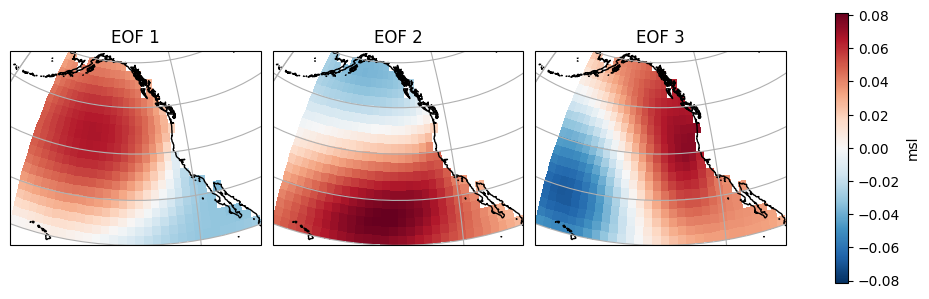

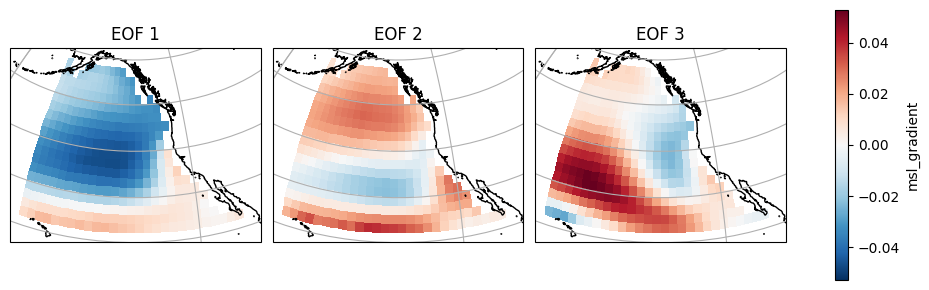

In [13]:
pca_grad.plot_eofs(vars_to_plot=["msl", "msl_gradient"], num_eofs=3, map_center=map_center)

## 8. Temporal indices with the gradient

The first three PCs of the combined **msl + spatial gradient** model, using the same full-record / 2015–2018 zoom layout as the pressure-only analysis. Percentages refer to the variance of the combined standardized feature set.


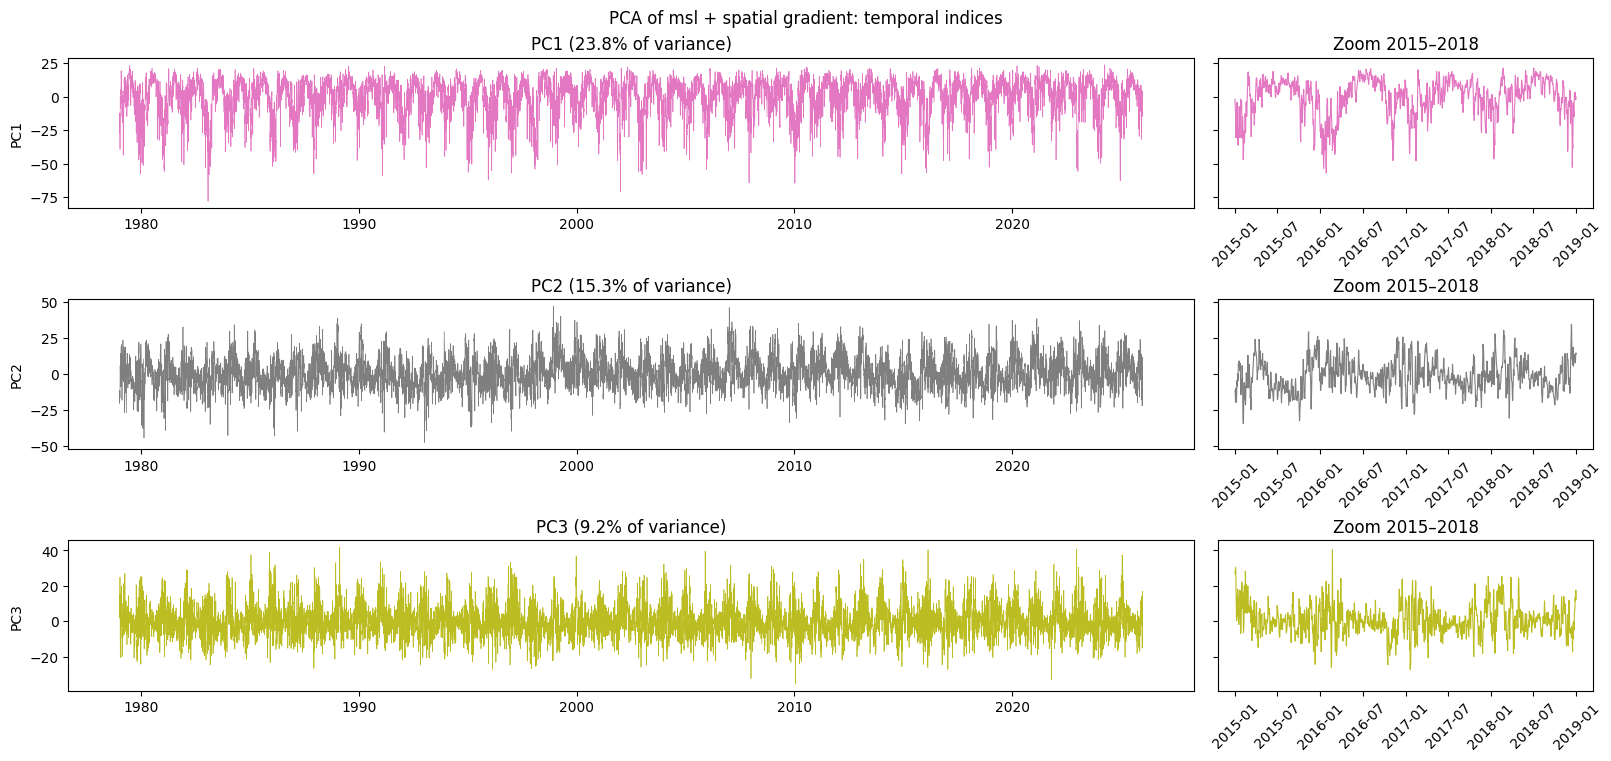

In [14]:
n_pcs_grad = min(3, pcs_grad.sizes["n_component"])
fig, axes = plt.subplots(
    n_pcs_grad, 2, figsize=(16, 2.5 * n_pcs_grad), sharey="row",
    layout="constrained", squeeze=False, gridspec_kw={"width_ratios": [3, 1]},
)
for i in range(n_pcs_grad):
    pc = pcs_grad.PCs.isel(n_component=i)
    ratio = pca_grad.explained_variance_ratio[i]
    color = f"C{i + 6}"
    axes[i, 0].plot(pc.time, pc, color=color, linewidth=0.5)
    axes[i, 0].set(ylabel=f"PC{i + 1}", title=f"PC{i + 1} ({ratio:.1%} of variance)")
    zoom = pc.sel(time=slice("2015", "2018"))
    axes[i, 1].plot(zoom.time, zoom, color=color, linewidth=0.8)
    axes[i, 1].set(title="Zoom 2015–2018")
    axes[i, 1].tick_params(axis="x", labelrotation=45)
fig.suptitle("PCA of msl + spatial gradient: temporal indices");


## 9. Save both fitted models

Save the pressure-only PCA (95% variance) and the combined pressure + gradient PCA (20 components) in `toolkit/datamining/outputs/`. BlueMath saves the fitted model, scaler, spatial coordinates and PCs, omitting the large intermediate training matrices. New inputs must use the same 2° grid, hPa pressure units and preprocessing; the combined model also requires the same gradient predictor.

Ocean-only models use the `_ocean.pkl` suffix and store `ocean_mask`, `gradient_mask` and the mask source for reproducible preprocessing.


In [15]:
from pathlib import Path

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "toolkit" / "datamining").is_dir()
)
output_path = repo_root / "toolkit" / "datamining" / "outputs"
output_path.mkdir(parents=True, exist_ok=True)
model_paths = {
    "msl": output_path / f"pca_msl_{region_id}_1979-2025_2deg_ocean.pkl",
    "msl_gradient": output_path / f"pca_msl_gradient_{region_id}_1979-2025_2deg_ocean.pkl",
}
for name, model in [("msl", pca), ("msl_gradient", pca_grad)]:
    model.region_bounds = {"south": south, "north": north, "west": west, "east": east}
    model.region_id = region_id
    model.ocean_mask = ocean_mask
    model.gradient_mask = gradient_mask if name == "msl_gradient" else None
    model.land_mask_source = "Natural Earth 50m; grid-cell center must be ocean"
    # Write atomically so an interrupted save does not replace a valid model.
    temporary_path = model_paths[name].with_suffix(".tmp.pkl")
    model.save_model(str(temporary_path))
    temporary_path.replace(model_paths[name])
    print(f"Saved {name}: {model_paths[name]}")

# Reload later with the same BlueMath environment:
# from bluemath_tk.core.io import load_model
# pca_loaded = load_model(str(model_paths["msl"]))
# pca_grad_loaded = load_model(str(model_paths["msl_gradient"]))

Saved msl: /workspaces/BlueMath_Course_Corvallis/toolkit/datamining/outputs/pca_msl_north_pacific_20N-60N_165W-105W_1979-2025_2deg_ocean.pkl
Saved msl_gradient: /workspaces/BlueMath_Course_Corvallis/toolkit/datamining/outputs/pca_msl_gradient_north_pacific_20N-60N_165W-105W_1979-2025_2deg_ocean.pkl


## Summary

- Load the preprocessed 2° North Pacific pressure fields (1979–2025) from THREDDS.
- Mask land with Natural Earth 50m: retain only grid cells whose center is ocean.
- Fit a pressure-only PCA retaining 95% variance and a second PCA with pressure plus its spatial-gradient predictor.
- Interpret newly fitted regional EOFs and their daily PCs.
- Save both regional models with explicit domain metadata and filenames for the wave regressions.